# Copy files over

In [ ]:
!gsutil cp /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/Metabolites/all_metabolites.csv /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
CommandException: No URLs matched: /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/Metabolites/all_metabolites.csv


In [ ]:
!gsutil cp /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/Metabolites/metadataM.csv /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
CommandException: No URLs matched: /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/Metabolites/metadataM.csv


In [ ]:
import pandas as pd

In [ ]:
metadata=pd.read_csv("/content/metadataM.csv", index_col=0)
metadata.head()

,Group
ID,
NC1,NC
NC2,NC
NC3,NC
NC4,NC
NC5,NC


In [ ]:
import pandas as pd
import numpy as np

metabolic = pd.read_csv("/content/all_metabolites.csv")
metabolic.head()

,BIOCHEMICAL,SUPER_PATHWAY,SUB_PATHWAY,NC1,NC2,NC3,NC4,NC5,NC6,HFD1,...,HFD_M3,HFD_M4,HFD_M5,HFD_M6,HFD_MRS1,HFD_MRS2,HFD_MRS3,HFD_MRS4,HFD_MRS5,HFD_MRS6
0,(14 or 15)-methylpalmitate (a17:0 or i17:0),Lipid,"Fatty Acid, Branched",0.6316,0.6497,0.7552,0.5847,0.5030,0.5152,1.0804,...,1.0772,1.7512,1.3445,1.2088,1.6513,0.9314,0.8175,0.9253,1.0495,1.0025
1,(16 or 17)-methylstearate (a19:0 or i19:0),Lipid,"Fatty Acid, Branched",0.6710,0.5332,0.6034,0.6966,0.4040,0.4160,0.9684,...,0.8953,1.6459,1.3547,1.0493,1.3802,0.9789,0.8797,1.0211,1.3125,1.0949
2,(3'-5')-uridylyluridine,Nucleotide,Dinucleotide,1.3711,1.2455,1.2406,1.3580,1.2391,0.9788,0.6961,...,0.5132,1.3902,1.2284,0.7551,0.5132,0.8388,0.5789,0.8305,1.4654,1.4919
3,(N(1) + N(8))-acetylspermidine,Amino Acid,Polyamine Metabolism,1.0281,0.8638,0.7594,1.3493,1.2079,0.9844,0.6321,...,1.1274,1.1345,1.0867,1.4792,1.0211,0.9809,0.6812,1.1016,1.3973,0.6954
4,(R)-3-hydroxybutyrylcarnitine,Lipid,"Fatty Acid Metabolism (Acyl Carnitine, Hydroxy)",1.5750,1.0649,0.9169,1.5465,1.3678,2.3870,1.1070,...,0.9016,1.7580,1.3605,1.3980,1.0210,0.5834,0.9432,0.6308,0.8645,0.5140


# T Test code for each metabolite

## Select the columns

In [ ]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.7 MB/s eta 0:00:00


In [ ]:
metabolic.columns

Index(['BIOCHEMICAL', 'SUPER_PATHWAY', 'SUB_PATHWAY', 'NC1', 'NC2', 'NC3',
       'NC4', 'NC5', 'NC6', 'HFD1', 'HFD2', 'HFD3', 'HFD4', 'HFD5', 'HFD6',
       'HFD_R1', 'HFD_R2', 'HFD_R3', 'HFD_R4', 'HFD_R5', 'HFD_R6', 'HFD_S1',
       'HFD_S2', 'HFD_S3', 'HFD_S4', 'HFD_S5', 'HFD_S6', 'HFD_M1', 'HFD_M2',
       'HFD_M3', 'HFD_M4', 'HFD_M5', 'HFD_M6', 'HFD_MRS1', 'HFD_MRS2',
       'HFD_MRS3', 'HFD_MRS4', 'HFD_MRS5', 'HFD_MRS6'],
      dtype='object')

In [ ]:
long_df = metabolic.melt(
    id_vars=["BIOCHEMICAL", "SUPER_PATHWAY", "SUB_PATHWAY"],
    var_name="Sample",
    value_name="Value"
)

# join metadata (index-based)
long_df = long_df.join(metadata, on="Sample")

# clean values
long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")

In [ ]:
!pip install pingouin

In [ ]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import pingouin as pg

In [ ]:
results = []

for name, df in long_df.groupby("BIOCHEMICAL"):

    nc = df[df["Group"] == "NC"]["Value"].dropna()
    hfd = df[df["Group"] == "HFD"]["Value"].dropna()

    # require enough data
    if len(nc) < 2 or len(hfd) < 2:
        continue

    res = pg.ttest(nc, hfd).iloc[0]

    # fold change
    fc = hfd.mean() / nc.mean() if nc.mean() != 0 else np.nan

    results.append({
        "BIOCHEMICAL": name,
        "T": res["T"],
        "p_val": res["p_val"],
        "cohen_d": res["cohen_d"],
        "Fold_Change": fc
    })

results = pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment 

In [ ]:
results

,BIOCHEMICAL,T,p_val,cohen_d,Fold_Change
0,(14 or 15)-methylpalmitate (a17:0 or i17:0),-3.963350,0.002672,2.288241,2.092405
1,(16 or 17)-methylstearate (a19:0 or i19:0),-3.049988,0.012252,1.760911,2.068317
2,(3'-5')-uridylyluridine,5.880292,0.000155,3.394988,0.568309
3,(N(1) + N(8))-acetylspermidine,3.133314,0.010630,1.809020,0.711492
4,(R)-3-hydroxybutyrylcarnitine,2.207438,0.051785,1.274465,0.645488
...,...,...,...,...,...
688,valylglutamine,0.000290,0.999775,0.000167,0.999879
689,valylglycine,0.713823,0.491661,0.412126,0.904912
690,valylleucine,-4.548117,0.001061,2.625856,2.095814
691,xanthine,-0.924669,0.376912,0.533858,1.083461


In [ ]:
results["p_adj"] = pg.multicomp(results["p_val"], method="fdr_bh")[1]

In [ ]:
results["DE"] = np.where(results["p_adj"] < 0.05, "YES", "NO")

In [ ]:
results = results.sort_values("p_adj")
results
results.to_csv("signficant_metabolites.csv")

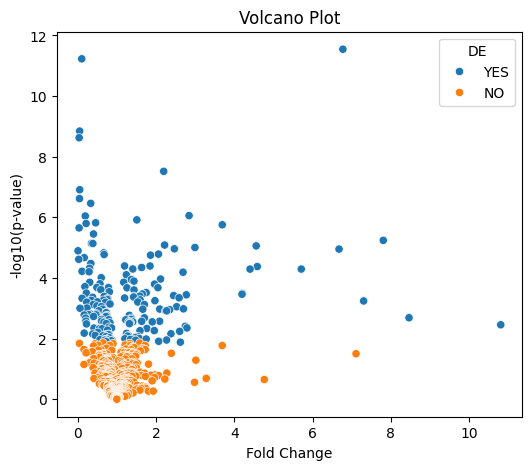

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=results,
    x="Fold_Change",
    y=-np.log10(results["p_val"]),
    hue="DE"
)

plt.xlabel("Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")

plt.show()
plt.savefig('figm1.png')
plt.savefig('figm1.pdf')


# Add scikit bio

In [ ]:
print(long_df.columns)

Index(['BIOCHEMICAL', 'SUPER_PATHWAY', 'SUB_PATHWAY', 'Sample', 'Value',
       'Group'],
      dtype='object')


In [ ]:
pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 29.9 MB/s eta 0:00:00


In [ ]:
metabolic.columns

Index(['BIOCHEMICAL', 'SUPER_PATHWAY', 'SUB_PATHWAY', 'NC1', 'NC2', 'NC3',
       'NC4', 'NC5', 'NC6', 'HFD1', 'HFD2', 'HFD3', 'HFD4', 'HFD5', 'HFD6',
       'HFD_R1', 'HFD_R2', 'HFD_R3', 'HFD_R4', 'HFD_R5', 'HFD_R6', 'HFD_S1',
       'HFD_S2', 'HFD_S3', 'HFD_S4', 'HFD_S5', 'HFD_S6', 'HFD_M1', 'HFD_M2',
       'HFD_M3', 'HFD_M4', 'HFD_M5', 'HFD_M6', 'HFD_MRS1', 'HFD_MRS2',
       'HFD_MRS3', 'HFD_MRS4', 'HFD_MRS5', 'HFD_MRS6'],
      dtype='object')

In [ ]:
metabolic

,BIOCHEMICAL,SUPER_PATHWAY,SUB_PATHWAY,NC1,NC2,NC3,NC4,NC5,NC6,HFD1,...,HFD_M3,HFD_M4,HFD_M5,HFD_M6,HFD_MRS1,HFD_MRS2,HFD_MRS3,HFD_MRS4,HFD_MRS5,HFD_MRS6
0,(14 or 15)-methylpalmitate (a17:0 or i17:0),Lipid,"Fatty Acid, Branched",0.6316,0.6497,0.7552,0.5847,0.5030,0.5152,1.0804,...,1.0772,1.7512,1.3445,1.2088,1.6513,0.9314,0.8175,0.9253,1.0495,1.0025
1,(16 or 17)-methylstearate (a19:0 or i19:0),Lipid,"Fatty Acid, Branched",0.6710,0.5332,0.6034,0.6966,0.4040,0.4160,0.9684,...,0.8953,1.6459,1.3547,1.0493,1.3802,0.9789,0.8797,1.0211,1.3125,1.0949
2,(3'-5')-uridylyluridine,Nucleotide,Dinucleotide,1.3711,1.2455,1.2406,1.3580,1.2391,0.9788,0.6961,...,0.5132,1.3902,1.2284,0.7551,0.5132,0.8388,0.5789,0.8305,1.4654,1.4919
3,(N(1) + N(8))-acetylspermidine,Amino Acid,Polyamine Metabolism,1.0281,0.8638,0.7594,1.3493,1.2079,0.9844,0.6321,...,1.1274,1.1345,1.0867,1.4792,1.0211,0.9809,0.6812,1.1016,1.3973,0.6954
4,(R)-3-hydroxybutyrylcarnitine,Lipid,"Fatty Acid Metabolism (Acyl Carnitine, Hydroxy)",1.5750,1.0649,0.9169,1.5465,1.3678,2.3870,1.1070,...,0.9016,1.7580,1.3605,1.3980,1.0210,0.5834,0.9432,0.6308,0.8645,0.5140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,valylglutamine,Peptide,Dipeptide,0.5803,0.8300,2.3517,1.6457,0.5832,0.6257,1.5156,...,0.5270,0.7698,0.5335,0.1725,2.7116,0.1725,0.1725,0.1725,0.1725,0.1725
689,valylglycine,Peptide,Dipeptide,1.2262,1.1472,1.2779,1.3430,0.7502,1.0471,1.3508,...,1.1311,1.3085,0.9941,0.6182,1.2986,0.1455,0.2229,0.5104,0.5687,0.7022
690,valylleucine,Peptide,Dipeptide,0.5819,0.7506,0.9435,0.8133,0.4341,0.2610,1.5338,...,0.4862,0.8829,1.1081,0.7530,1.0283,0.9997,0.5407,1.0743,1.4344,1.2022
691,xanthine,Nucleotide,"Purine Metabolism, (Hypo)Xanthine/Inosine cont...",0.9808,0.8194,0.9845,1.0453,0.9728,1.0490,1.0769,...,0.8664,1.4702,0.9457,0.9989,1.2968,1.1501,1.1118,0.7663,0.9266,0.8323


In [ ]:
from scipy.spatial.distance import pdist, squareform
from skbio.stats.ordination import pcoa

# this is set for jud
metabolites2 = metabolic.iloc[:, 3:39]

betaMB = squareform(pdist(metabolites2.T, metric='braycurtis'))

brayMB = pcoa(betaMB)
brayMB_df = brayMB.samples

/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


In [ ]:
from skbio.diversity import beta_diversity

In [ ]:
metabolites2.T

,0,1,2,3,4,5,6,7,8,9,...,683,684,685,686,687,688,689,690,691,692
NC1,0.6316,0.6710,1.3711,1.0281,1.5750,1.3501,1.0458,1.3215,1.0605,1.0317,...,0.7948,0.7867,1.2667,0.7871,1.1643,0.5803,1.2262,0.5819,0.9808,1.3044
NC2,0.6497,0.5332,1.2455,0.8638,1.0649,2.1309,1.0507,1.0859,0.9578,0.8791,...,1.0922,1.1917,0.5780,2.2729,0.8281,0.8300,1.1472,0.7506,0.8194,1.2534
NC3,0.7552,0.6034,1.2406,0.7594,0.9169,0.9430,1.0454,1.0782,0.7885,1.0581,...,0.8311,1.0589,1.0176,2.1565,0.8943,2.3517,1.2779,0.9435,0.9845,1.7406
NC4,0.5847,0.6966,1.3580,1.3493,1.5465,1.3840,1.0341,1.5316,1.5615,1.0846,...,0.5748,0.7889,0.8683,0.6982,0.9885,1.6457,1.3430,0.8133,1.0453,1.0909
NC5,0.5030,0.4040,1.2391,1.2079,1.3678,1.7022,0.9032,0.7771,1.0163,1.0003,...,0.8640,0.7106,1.8578,0.5626,0.7262,0.5832,0.7502,0.4341,0.9728,0.9958
NC6,0.5152,0.4160,0.9788,0.9844,2.3870,2.1017,0.7137,0.5898,0.8688,1.0016,...,0.7295,0.9950,0.7304,0.9545,0.8319,0.6257,1.0471,0.2610,1.0490,1.8297
HFD1,1.0804,0.9684,0.6961,0.6321,1.1070,0.7428,0.8121,0.6357,0.8549,1.0442,...,1.0319,1.4456,0.7153,1.4640,1.0527,1.5156,1.3508,1.5338,1.0769,0.9871
HFD2,0.9258,0.7755,0.8625,0.6637,0.9461,0.9807,0.9529,0.9052,0.8395,0.9650,...,1.0000,1.4466,0.5822,0.8136,0.8186,0.9481,0.9738,1.0885,1.0011,0.9581
HFD3,0.9775,0.7276,0.9534,0.7429,0.6909,0.8475,0.9591,1.0113,0.7313,1.0552,...,1.0095,1.2191,2.2532,1.1430,0.8992,0.3840,0.6047,1.1566,0.9913,1.4278
HFD4,1.2798,1.1839,0.5597,0.8417,0.7807,0.8435,0.7743,0.4778,1.1870,0.9683,...,0.8500,1.0050,0.8095,0.9722,0.8019,2.5437,1.2726,1.6298,0.9869,0.8353


In [ ]:
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

feature_dist = beta_diversity('braycurtis', metabolites2.T)
pc = pcoa(feature_dist)

pc.samples.iloc[:, :5]

/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


,PC1,PC2,PC3,PC4,PC5
NC1,-0.252894,-0.000897,0.003612,0.002677,0.037379
NC2,-0.254960,0.046165,0.006350,0.035260,0.031522
NC3,-0.227487,0.001214,-0.000494,0.017165,-0.006384
NC4,-0.220903,0.019093,-0.040882,-0.055518,-0.060845
NC5,-0.244475,-0.032977,0.048118,-0.013058,-0.002066
NC6,-0.219508,-0.006658,0.021541,-0.019712,-0.004225
HFD1,0.049372,-0.013569,-0.022163,-0.019093,-0.004881
HFD2,0.059693,0.017754,0.035659,-0.021108,-0.029988
HFD3,0.060630,0.028903,0.035967,-0.024877,-0.070400
HFD4,0.031166,-0.048427,0.000149,0.027348,-0.001659


In [ ]:
pc.proportion_explained

,0
PC1,0.364586
PC2,0.104360
PC3,0.082259
PC4,0.065821
PC5,0.046454
PC6,0.045832
PC7,0.033082
PC8,0.028376
PC9,0.026245
PC10,0.020904


In [ ]:
metadata = metadata.reindex(pc.samples.index)

In [ ]:
print(metadata["Sample"].index.unique())

Index(['NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'HFD1', 'HFD2', 'HFD3',
       'HFD4', 'HFD5', 'HFD6', 'HFD_R1', 'HFD_R2', 'HFD_R3', 'HFD_R4',
       'HFD_R5', 'HFD_R6', 'HFD_S1', 'HFD_S2', 'HFD_S3', 'HFD_S4', 'HFD_S5',
       'HFD_S6', 'HFD_M1', 'HFD_M2', 'HFD_M3', 'HFD_M4', 'HFD_M5', 'HFD_M6',
       'HFD_MRS1', 'HFD_MRS2', 'HFD_MRS3', 'HFD_MRS4', 'HFD_MRS5', 'HFD_MRS6'],
      dtype='object')


In [ ]:
metadata["Group"] = metadata["Group"].replace({
    "HFDM": "HFD+meso",
    "HFDR": "HFD+R",
    "HFDS": "HFD+S",
    "HFDMRS": "HFD+mixed",
    "HFD": "HFD",
    "NC": "NC"
})
order = ["NC", "HFD", "HFD+meso", "HFD+R", "HFD+S", "HFD+mixed"]

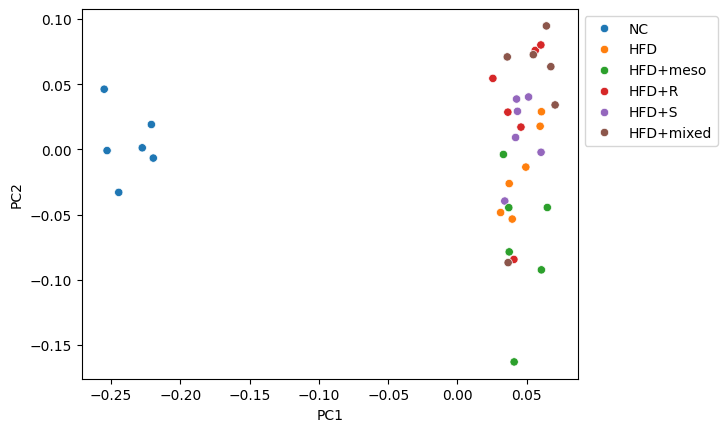

<Figure size 400x600 with 0 Axes>

In [ ]:
sns.scatterplot(x=pc.samples.PC1, y=pc.samples.PC2, hue=metadata.Group, hue_order=order)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.figure(figsize=(4, 6))
plt.savefig('figm2.png')
plt.savefig('figm2.pdf')

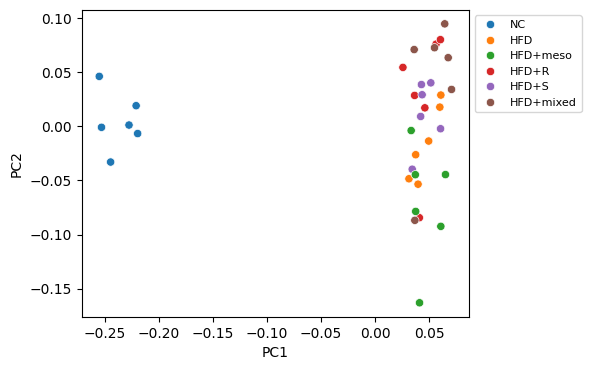

In [ ]:
fig, ax = plt.subplots(figsize=(5, 9))

sns.scatterplot(
    x=pc.samples.PC1,
    y=pc.samples.PC2,
    hue=metadata.Group,
    hue_order=order,
    ax=ax
)

ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)


fig.savefig('figm2.png', dpi=300)
fig.savefig('figm2.pdf')

In [ ]:
from skbio.stats.distance import permanova

In [ ]:
permanova(feature_dist,metadata.Group)

,PERMANOVA results
method name,PERMANOVA
test statistic name,pseudo-F
sample size,36
number of groups,6
test statistic,5.474706
p-value,0.001
number of permutations,999


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
metadata['Sample']=metadata.index

In [ ]:
print(metadata["Sample"].index.unique())

Index(['NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'HFD1', 'HFD2', 'HFD3',
       'HFD4', 'HFD5', 'HFD6', 'HFD_R1', 'HFD_R2', 'HFD_R3', 'HFD_R4',
       'HFD_R5', 'HFD_R6', 'HFD_S1', 'HFD_S2', 'HFD_S3', 'HFD_S4', 'HFD_S5',
       'HFD_S6', 'HFD_M1', 'HFD_M2', 'HFD_M3', 'HFD_M4', 'HFD_M5', 'HFD_M6',
       'HFD_MRS1', 'HFD_MRS2', 'HFD_MRS3', 'HFD_MRS4', 'HFD_MRS5', 'HFD_MRS6'],
      dtype='object')


In [ ]:
metadata["Group"] = metadata["Group"].replace({
    "HFDM": "HFD+meso",
    "HFDR": "HFD+R",
    "HFDS": "HFD+S",
    "HFDMRS": "HFD+mixed",
    "HFD": "HFD",
    "NC": "NC"
})
order = ["NC", "HFD", "HFD+meso", "HFD+R", "HFD+S", "HFD+mixed"]

/tmp/ipykernel_6209/2813922188.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)


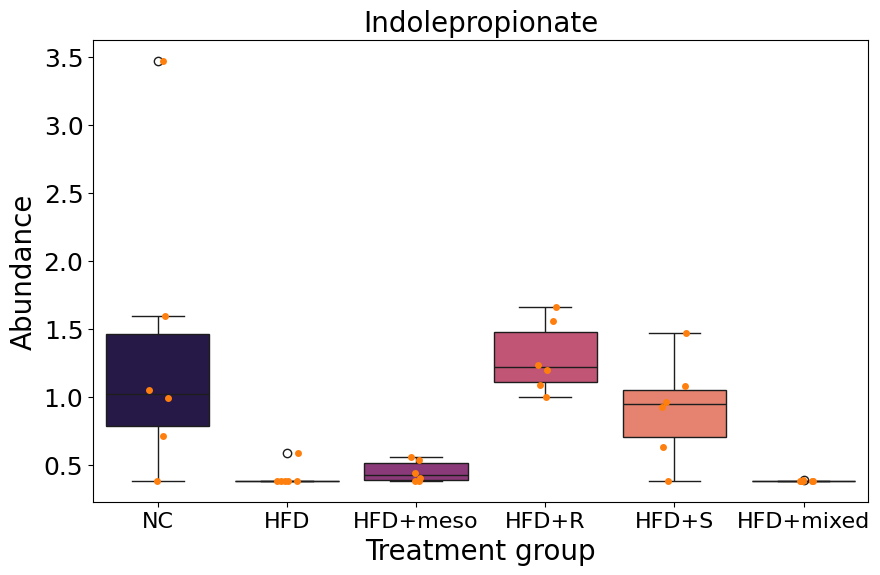

In [ ]:

# Select the metabolites you want to plot
metabolite=["indolepropionate"]

sample_data=metabolic[metabolic["BIOCHEMICAL"].isin(metabolite)]

# Drop identifier columns for plotting, making sure to operate on sample_data
sample_data = sample_data.drop(columns=["BIOCHEMICAL", "SUPER_PATHWAY", "SUB_PATHWAY"])

# Prepare data for plotting
long_df = sample_data.T.reset_index()
long_df.columns = ["Sample", "Value"]

# Ensure metadata is in a compatible format and merge
metadata_reset = metadata.reset_index().rename(columns={"ID": "Sample"})

merged = pd.merge(long_df, metadata_reset, on="Sample")

# Define metabolite_name for the plot title
metabolite_name = metabolite[0]

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)
sns.stripplot(data=merged, x="Group", y="Value", jitter=True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.title(metabolite_name.capitalize(), fontsize=20)
plt.xlabel('Treatment group', fontsize=20)
plt.ylabel('Abundance', fontsize=20)


plt.show()

/tmp/ipykernel_6209/566730607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)


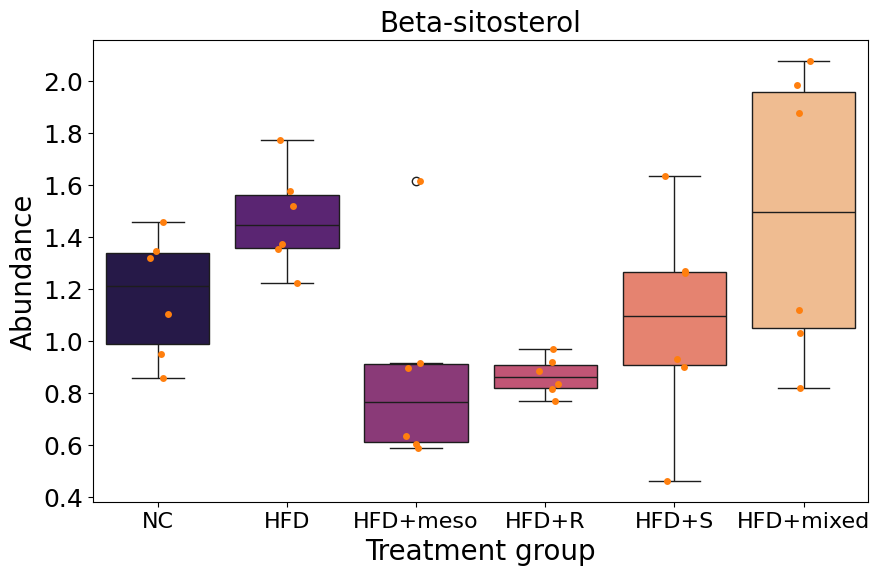

In [ ]:

# Select the metabolites you want to plot
metabolite=["beta-sitosterol"]

sample_data=metabolic[metabolic["BIOCHEMICAL"].isin(metabolite)]

# Drop identifier columns for plotting, making sure to operate on sample_data
sample_data = sample_data.drop(columns=["BIOCHEMICAL", "SUPER_PATHWAY", "SUB_PATHWAY"])

# Prepare data for plotting
long_df = sample_data.T.reset_index()
long_df.columns = ["Sample", "Value"]

# Ensure metadata is in a compatible format and merge
metadata_reset = metadata.reset_index().rename(columns={"ID": "Sample"})

merged = pd.merge(long_df, metadata_reset, on="Sample")

# Define metabolite_name for the plot title
metabolite_name = metabolite[0]

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)
sns.stripplot(data=merged, x="Group", y="Value", jitter=True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.title(metabolite_name.capitalize(), fontsize=20)
plt.xlabel('Treatment group', fontsize=20)
plt.ylabel('Abundance', fontsize=20)


plt.show()

/tmp/ipykernel_6209/2920235320.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)


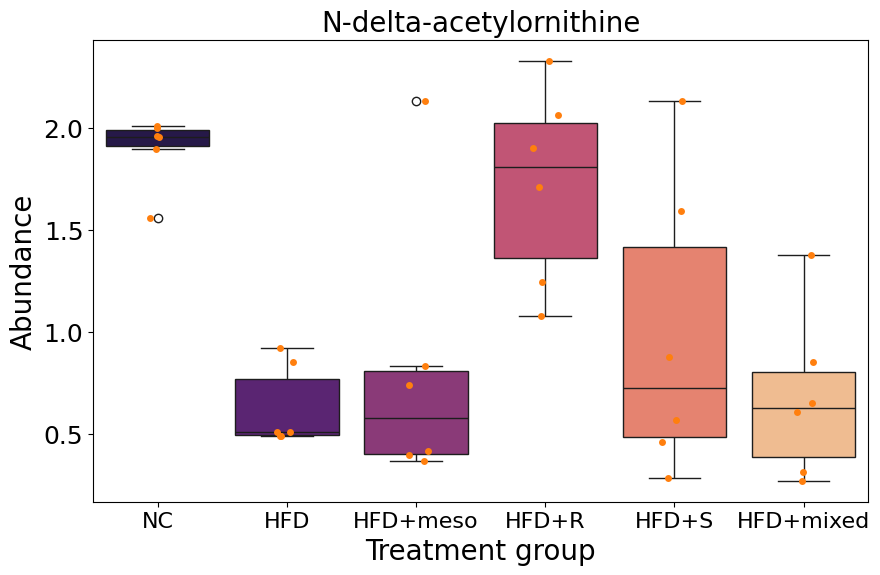

In [ ]:

# Select the metabolites you want to plot
metabolite=["N-delta-acetylornithine"]

sample_data=metabolic[metabolic["BIOCHEMICAL"].isin(metabolite)]

# Drop identifier columns for plotting, making sure to operate on sample_data
sample_data = sample_data.drop(columns=["BIOCHEMICAL", "SUPER_PATHWAY", "SUB_PATHWAY"])

# Prepare data for plotting
long_df = sample_data.T.reset_index()
long_df.columns = ["Sample", "Value"]

# Ensure metadata is in a compatible format and merge
metadata_reset = metadata.reset_index().rename(columns={"ID": "Sample"})

merged = pd.merge(long_df, metadata_reset, on="Sample")

# Define metabolite_name for the plot title
metabolite_name = metabolite[0]

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)
sns.stripplot(data=merged, x="Group", y="Value", jitter=True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.title(metabolite_name.capitalize(), fontsize=20)
plt.xlabel('Treatment group', fontsize=20)
plt.ylabel('Abundance', fontsize=20)


plt.show()

/tmp/ipykernel_6209/1419272117.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)


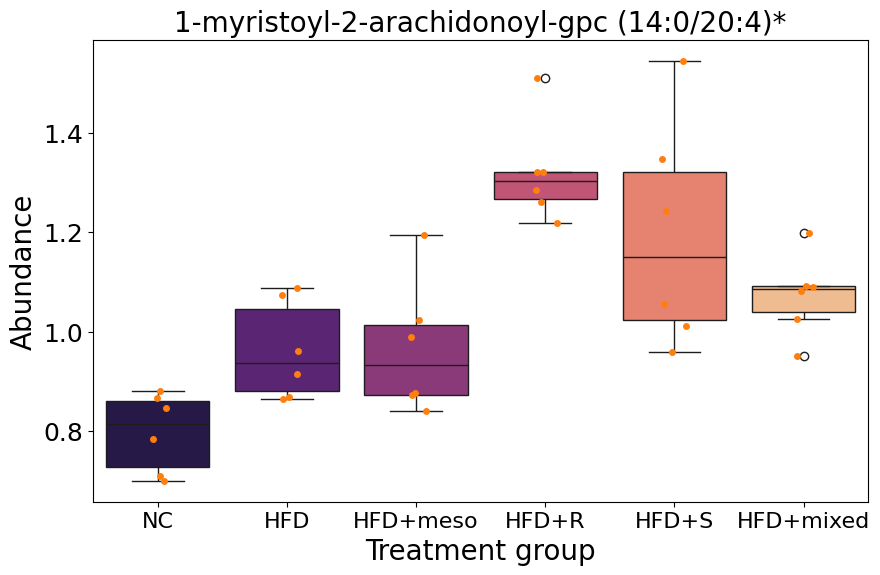

In [ ]:

# Select the metabolites you want to plot
metabolite=["1-myristoyl-2-arachidonoyl-GPC (14:0/20:4)*"]

sample_data=metabolic[metabolic["BIOCHEMICAL"].isin(metabolite)]

# Drop identifier columns for plotting, making sure to operate on sample_data
sample_data = sample_data.drop(columns=["BIOCHEMICAL", "SUPER_PATHWAY", "SUB_PATHWAY"])

# Prepare data for plotting
long_df = sample_data.T.reset_index()
long_df.columns = ["Sample", "Value"]

# Ensure metadata is in a compatible format and merge
metadata_reset = metadata.reset_index().rename(columns={"ID": "Sample"})

merged = pd.merge(long_df, metadata_reset, on="Sample")

# Define metabolite_name for the plot title
metabolite_name = metabolite[0]

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="Group", y="Value", palette='magma', order=order)
sns.stripplot(data=merged, x="Group", y="Value", jitter=True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.title(metabolite_name.capitalize(), fontsize=20)
plt.xlabel('Treatment group', fontsize=20)
plt.ylabel('Abundance', fontsize=20)


plt.show()